In [24]:
import numpy as np
import matplotlib.pyplot as plt

# --- Spar Buoy Properties ---
# We'll define a coordinate system 'x' starting from the spar base (x=0) to the top (x=130m).
# This corresponds to a vertical position 'z' from z=-120m to z=+10m relative to Still Water Level (SWL).
# x = z + 120

# 1. Geometric Properties
L = 130.0       # Total length of the spar [m]
D_upper = 6.5   # Platform Diameter Above Taper [m]
D_lower = 9.4   # Platform Diameter Below Taper [m]
x_taper_bottom = 108.0 # Position of the bottom of the taper (z=-12m) [m]
x_taper_top = 116.0    # Position of the top of the taper (z=-4m) [m]

def get_diameter(x):
    """
    Returns the diameter of the spar at a given position x (or array of positions)
    along its length, using linear interpolation for the tapered section.
    """
    # Define the points where the diameter changes
    xp = [0, x_taper_bottom, x_taper_top, L]
    # Define the diameter at those points
    fp = [D_lower, D_lower, D_upper, D_upper]
    return np.interp(x, xp, fp)

def get_area(x):
    """
    Returns the cross-sectional area A(x).
    NOTE: Assumes solid circular section temporarily for code structure.
    """
    return np.pi * (get_diameter(x) / 2)**2

def get_second_moment_of_area(x):
    """
    Returns the second moment of area I(x).
    """
    return np.pi * (get_diameter(x) / 2)**4 / 4

# 2. Material and Mass Properties
E = 210e9       # Young's Modulus for steel [Pa]
total_mass = 7466330.0 # Platform Mass, Including Ballast [kg]

# Effective density (Temporary simplification to distribute mass over volume)
V_bottom_cyl = np.pi * (D_lower/2)**2 * x_taper_bottom
V_taper = np.pi/3 * (x_taper_top - x_taper_bottom) * ((D_lower/2)**2 + (D_lower/2)*(D_upper/2) + (D_upper/2)**2)
V_top_cyl = np.pi * (D_upper/2)**2 * (L - x_taper_top)
total_volume = V_bottom_cyl + V_taper + V_top_cyl
rho_eff = total_mass / total_volume # Effective average density [kg/m^3]

# 3. Boundary Conditions & Loads (Placeholders)
u0 = 0          
u0_dt2 = 0      
du0 = 0         
du0_dt2 = 0     

def q(x, t):
    """Placeholder for distributed loads."""
    return 0.0


In [25]:
ne = 130        # Increased number of elements (1 element per meter)
nn = ne + 1
ndofs = 2*nn
xn = np.linspace(0, L, nn)

In [26]:
elem_dofs = []
dof_node = []
for ie in np.arange(0, ne):
    elem_dofs.append(np.arange(2*ie, 2*ie + 4))
for idof in np.arange(0, ndofs):
    dof_node.append(int(np.floor(idof/2)))

In [27]:
N_k = []
dN_k = []
ddN_k = []
h = L/ne
matrix = np.array([[1, 0, 0, 0], [0, 1, 0, 0], [1, h,  h**2, h**3], [0, 1, 2*h, 3*h**2]])

def base(x):
    if isinstance(x, float):
        return np.array([[1], [x], [x**2], [x**3]])
    else:
        return np.array([[np.ones(len(x))], [x], [x**2], [x**3]])
def dbase(x):
    if isinstance(x, float):
        return np.array([[0], [1], [2*x], [3*x**2]])
    else:
        return np.array([[np.zeros(len(x))], [np.ones(len(x))], [2*x], [3*x**2]])
def ddbase(x):
    if isinstance(x, float):
        return np.array([[0], [0], [2], [6*x]])
    else:
        return np.array([[np.zeros(len(x))], [np.zeros(len(x))], [2*np.ones(len(x))], [6*x]])
def make_N(coeff): 
    return lambda x: np.dot(np.transpose(base(x)), coeff)
def make_dN(coeff):
    return lambda x: np.dot(np.transpose(dbase(x)), coeff)
def make_ddN(coeff):
    return lambda x: np.dot(np.transpose(ddbase(x)), coeff)

dof_vec = np.arange(0,4)
for idof in dof_vec:
    rhs = np.zeros(len(dof_vec))
    rhs[idof] = 1
    coeff = np.linalg.solve(matrix, rhs)
    N_k.append(make_N(coeff))
    dN_k.append(make_dN(coeff))
    ddN_k.append(make_ddN(coeff))

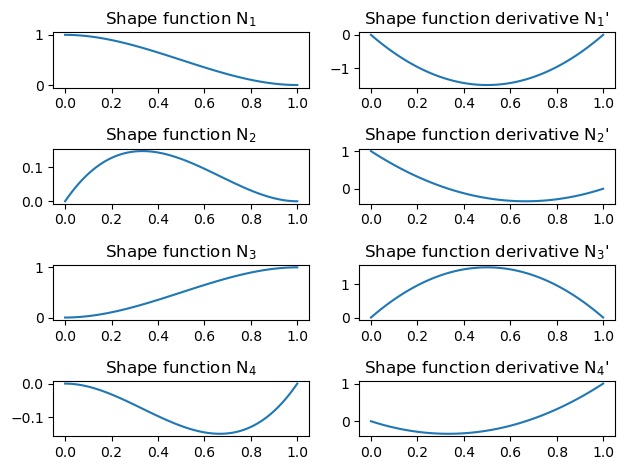

In [28]:
xplot = np.arange(0, h + h/100, h/100)

fig, axs = plt.subplots(4, 2)
axs[0, 0].plot(xplot, N_k[0](xplot))
axs[0, 0].set_title("Shape function N$_1$")
axs[0, 1].plot(xplot, dN_k[0](xplot))
axs[0, 1].set_title("Shape function derivative N$_1$'")
axs[1, 0].plot(xplot, N_k[1](xplot))
axs[1, 0].set_title("Shape function N$_2$")
axs[1, 1].plot(xplot, dN_k[1](xplot))
axs[1, 1].set_title("Shape function derivative N$_2$'")
axs[2, 0].plot(xplot, N_k[2](xplot))
axs[2, 0].set_title("Shape function N$_3$")
axs[2, 1].plot(xplot, dN_k[2](xplot))
axs[2, 1].set_title("Shape function derivative N$_3$'")
axs[3, 0].plot(xplot, N_k[3](xplot))
axs[3, 0].set_title("Shape function N$_4$")
axs[3, 1].plot(xplot, dN_k[3](xplot))
axs[3, 1].set_title("Shape function derivative N$_4$'")

# automatically fix subplot spacing
plt.tight_layout()

In [31]:
import scipy.integrate as scp

# We now need to calculate a separate Mass and Stiffness matrix for EACH element,
# because the geometry (A and I) varies along the length of the spar.
# We will store them in lists.
M_list = []
K_list = []

# Loop over each element to compute its unique matrices
for ie in range(ne):
    # Get the global coordinate of the start of the element
    x_start = xn[ie]

    # Create the 4x4 element matrices for this specific element
    M_k = np.zeros((4, 4))
    K_k = np.zeros((4, 4))

    # The integration for the element matrices is done in a local coordinate system
    # (from 0 to h). We must map this local coordinate to the global coordinate
    # to get the correct properties A(x) and I(x) during integration.
    # global_x = x_start + local_x

    for idof in range(4):
        for jdof in range(4):
            # Integrand for the Mass matrix
            def eqn_M(local_x):
                global_x = x_start + local_x
                # Use effective density and area function
                return rho_eff * get_area(global_x) * N_k[idof](local_x) * N_k[jdof](local_x)

            # Integrand for the Stiffness matrix
            def eqn_K(local_x):
                global_x = x_start + local_x
                # Use Young's modulus and second moment of area function
                return E * get_second_moment_of_area(global_x) * ddN_k[idof](local_x) * ddN_k[jdof](local_x)

            # Perform the numerical integration over the element length h
            M_k[idof, jdof] = scp.quad(eqn_M, 0, h)[0]
            K_k[idof, jdof] = scp.quad(eqn_K, 0, h)[0]

    # Add the calculated matrices for this element to our lists
    M_list.append(M_k)
    K_list.append(K_k)

print(f"Successfully calculated {len(K_list)} unique element stiffness matrices.")


Successfully calculated 130 unique element stiffness matrices.


In [32]:
# Initialize global Mass and Stiffness matrices with zeros
# ndofs is the total number of Degrees of Freedom (2 * number of nodes)
M_global = np.zeros((ndofs, ndofs))
K_global = np.zeros((ndofs, ndofs))

# Assemble the global matrices
for ie in range(ne):
    # Get the global degrees of freedom for the current element
    dofs = elem_dofs[ie]
    
    # Add the element matrices to the corresponding locations in the global matrices
    # np.ix_ creates a meshgrid of indices to correctly slice the 2D global matrix
    M_global[np.ix_(dofs, dofs)] += M_list[ie]
    K_global[np.ix_(dofs, dofs)] += K_list[ie]

print(f"Global matrices assembled successfully!")
print(f"Shape of global matrices: {K_global.shape} (Should be 262x262 for 130 elements)")


Global matrices assembled successfully!
Shape of global matrices: (262, 262) (Should be 262x262 for 130 elements)


In [30]:
K = np.zeros((ndofs*ndofs))       # 1-D array for global stiffness matrix
M = np.zeros((ndofs*ndofs))       # 1-D array for global mass matrix
Q = np.zeros(ndofs)               # 1-D array for Q vector

for ie in np.arange(0, ne):
    # Get the nodes of the elements
    dofs = elem_dofs[ie]
    NodeLeft = dof_node[dofs[0]]
    NodeRight = dof_node[dofs[-1]]
    
    # Get the degrees of freedom that correspond to each node
    Dofs_Left = 2*(NodeLeft) + np.arange(0, 2)
    Dofs_Right = 2*(NodeRight) + np.arange(0, 2)

    # Assemble the matrices at the correct place
    nodes = np.append(Dofs_Left, Dofs_Right)
    for i in np.arange(0, 4):
        Q[nodes[i]] = Q[nodes[i]] + Q2_k[ie][i]
        for j in np.arange(0, 4):
            ij = nodes[j] + nodes[i]*ndofs
            M[ij] = M[ij] + M_k[i, j]
            K[ij] = K[ij] + K_k[i, j]
            
# Reshape the global matrix from a 1-D array to a 2-D array
M = M.reshape((ndofs, ndofs))
K = K.reshape((ndofs, ndofs))

# Transform the Q vector into functions dependent on time
Q_vector = []
for i in np.arange(0, ndofs):
    Q_vector.append(lambda t: Q[i] + 10e3*np.sin(2*np.pi*t))
    # Q_vector.append(lambda t: Q[i] + 0.02*t)
    # This does not seem to be correct??

NameError: name 'Q2_k' is not defined

In [ ]:
plt.figure()
plt.spy(M);

In [ ]:
plt.figure()
plt.spy(K);

In [ ]:
fixed_dofs = np.arange(0, 2)                    # fixed DOFs
free_dofs = np.arange(0, ndofs)                 # free DOFs
free_dofs = np.delete(free_dofs, fixed_dofs)    # remove the fixed DOFs from the free DOFs array

# free & fixed array indices
fx = free_dofs[:, np.newaxis]
fy = free_dofs[np.newaxis, :]
bx = fixed_dofs[:, np.newaxis]
by = fixed_dofs[np.newaxis, :]

In [ ]:
# Mass
Mii = M[fx, fy]
Mib = M[fx, by]
Mbi = M[bx, fy]
Mbb = M[bx, by]

# Stiffness
Kii = K[fx, fy]
Kib = K[fx, by]
Kbi = K[bx, fy]
Kbb = K[bx, by]

In [ ]:
ub = np.array([u0, du0])
ub_dt2 = np.array([u0_dt2, du0_dt2])
RHS = -np.dot(Mib, ub_dt2) - np.dot(Kib, ub)

In [ ]:
# Construct a matrix to reshape Q 
R = np.identity(ndofs)
R = R[fx, 0:ndofs]

# Set Dimensions and initial conditions of state vector
nfdofs = len(free_dofs)
udofs = np.arange(0, nfdofs)
vdofs = np.arange(nfdofs, 2*nfdofs)
q0 = np.zeros((2*nfdofs))

# Time span (output purposes)
tf = 5
tspan = np.arange(0, tf, tf/1e3)

# Solve
def odefun(t, q):
    return np.append(q[vdofs], np.linalg.solve(Mii, np.transpose(np.dot(R, Q).reshape(1,-1) + RHS - np.dot(Kii, q0[udofs])))).tolist()

sol = scp.solve_ivp(fun=odefun, t_span=[tspan[0], tspan[-1]], y0=q0, t_eval=tspan)  

# Plot results
plt.figure()
plt.plot(sol.t,sol.y[nfdofs-1])
plt.xlabel('Time [s]')
plt.ylabel("Deflection [m]")
plt.title("Beam end deflection");